# Supermarket Sales ETL Pipeline
## Extract → Transform → Load → Report

This notebook:
1. Extracts supermarket sales data from Kaggle
2. Transforms it into dimension and fact tables
3. Loads it into SQLite (local) or BigQuery (cloud)
4. Generates an analytical report with window functions

In [1]:
# Run this cell once to install required packages
import sys
!{sys.executable} -m pip install kagglehub pandas matplotlib seaborn sqlalchemy

Import Libraries

In [2]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
plt.style.use("seaborn-v0_8")

print("Libraries loaded successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully!


 Extract Data from Kaggle

 ## Step 1 — Extract
Download the supermarket sales dataset from Kaggle using kagglehub.

Download Dataset

# Download dataset from Kaggle


In [3]:
dataset_dir = kagglehub.dataset_download(
    "lovishbansal123/sales-of-a-supermarket"
)
print("Dataset downloaded to:", dataset_dir)

# Find CSV file
csv_files = []
for root, _, files in os.walk(dataset_dir):
    for f in files:
        if f.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, f))

print("CSV files found:", csv_files)

Dataset downloaded to: /Users/sonicakalmangi/.cache/kagglehub/datasets/lovishbansal123/sales-of-a-supermarket/versions/1
CSV files found: ['/Users/sonicakalmangi/.cache/kagglehub/datasets/lovishbansal123/sales-of-a-supermarket/versions/1/supermarket_sales.csv']


Load Raw Data

In [4]:
# Load into DataFrame
df_raw = pd.read_csv(csv_files[0])

print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head()

Shape: (1000, 17)
Columns: ['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.14,548.97,1/5/2019,13:08,Ewallet,522.83,4.76,26.14,9.10
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.82,80.22,3/8/2019,10:29,Cash,76.40,4.76,3.82,9.60
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.22,340.53,3/3/2019,13:23,Credit card,324.31,4.76,16.22,7.40
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.29,489.05,1/27/2019,20:33,Ewallet,465.76,4.76,23.29,8.40
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.21,634.38,2/8/2019,10:37,Ewallet,604.17,4.76,30.21,5.30


## Step 2 — Explore
Understand the dataset structure before transforming.

In [5]:
# Basic statistics
print("=== Dataset Info ===")
df_raw.info()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin pe

In [6]:
# Descriptive statistics
df_raw.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,55.67,5.51,15.38,322.97,307.59,4.76,15.38,6.97
std,26.49,2.92,11.71,245.89,234.18,0.00,11.71,1.72
min,10.08,1.00,0.51,10.68,10.17,4.76,0.51,4.00
25%,32.88,3.00,5.92,124.42,118.50,4.76,5.92,5.50
50%,55.23,5.00,12.09,253.85,241.76,4.76,12.09,7.00
75%,77.94,8.00,22.45,471.35,448.91,4.76,22.45,8.50
max,99.96,10.00,49.65,1042.65,993.00,4.76,49.65,10.00


In [7]:
# Check for nulls
missing = df_raw.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values!")

Missing values per column:
No missing values!


In [8]:
# Check for duplicates
dupes = df_raw.duplicated().sum()
print(f"Duplicate rows: {dupes}")

Duplicate rows: 0


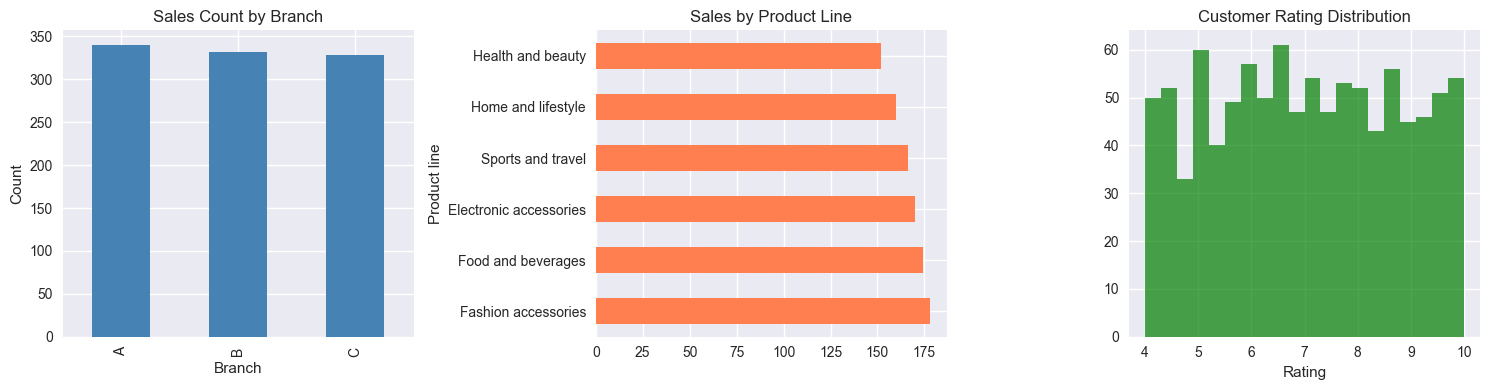

In [9]:
# Sales by Branch
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Branch distribution
df_raw["Branch"].value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("Sales Count by Branch")
axes[0].set_xlabel("Branch")
axes[0].set_ylabel("Count")

# Product line distribution
df_raw["Product line"].value_counts().plot(
    kind="barh", ax=axes[1], color="coral"
)
axes[1].set_title("Sales by Product Line")

# Rating distribution
axes[2].hist(df_raw["Rating"], bins=20, color="green", alpha=0.7)
axes[2].set_title("Customer Rating Distribution")
axes[2].set_xlabel("Rating")

plt.tight_layout()
plt.show()

## Step 3 — Transform
Clean the data and build dimension and fact tables.
### Schema Design
- **dim_branch** — Branch code and city
- **dim_product** — Product line
- **fact_sales** — Sales transactions

In [11]:
# Standardize column names
df = df_raw.copy()
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
              .str.replace("%", "pct")
              .str.replace("-", "_")
)

rename_map = {
    "tax_5pct":               "tax_amount",
    "tax_5%":                 "tax_amount",
    "total":                  "total_amount",
    "date":                   "sale_date",
    "time":                   "sale_time",
    "payment":                "payment_method",
    "gross_margin_percentage":"gross_margin_pct"
}
df = df.rename(columns={c: rename_map.get(c, c) for c in df.columns})
df["sale_date"] = pd.to_datetime(
    df["sale_date"], errors="coerce"
).dt.strftime("%Y-%m-%d")

print("Cleaned columns:", list(df.columns))
df.head()

Cleaned columns: ['invoice_id', 'branch', 'city', 'customer_type', 'gender', 'product_line', 'unit_price', 'quantity', 'tax_amount', 'total_amount', 'sale_date', 'sale_time', 'payment_method', 'cogs', 'gross_margin_pct', 'gross_income', 'rating']


,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_amount,total_amount,sale_date,sale_time,payment_method,cogs,gross_margin_pct,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.14,548.97,2019-01-05,13:08,Ewallet,522.83,4.76,26.14,9.10
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.82,80.22,2019-03-08,10:29,Cash,76.40,4.76,3.82,9.60
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.22,340.53,2019-03-03,13:23,Credit card,324.31,4.76,16.22,7.40
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.29,489.05,2019-01-27,20:33,Ewallet,465.76,4.76,23.29,8.40
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.21,634.38,2019-02-08,10:37,Ewallet,604.17,4.76,30.21,5.30


In [12]:
# dim_branch
dim_branch = (
    df[["branch", "city"]]
    .drop_duplicates()
    .sort_values(["branch", "city"])
    .reset_index(drop=True)
)
dim_branch["branch_key"] = dim_branch.index + 1
dim_branch = dim_branch.rename(columns={"branch": "branch_code"})
dim_branch = dim_branch[["branch_key", "branch_code", "city"]]

print(f"dim_branch: {len(dim_branch)} rows")
dim_branch

dim_branch: 3 rows


,branch_key,branch_code,city
0,1,A,Yangon
1,2,B,Mandalay
2,3,C,Naypyitaw


In [13]:
# dim_product
dim_product = (
    df[["product_line"]]
    .drop_duplicates()
    .sort_values("product_line")
    .reset_index(drop=True)
)
dim_product["product_key"] = dim_product.index + 1
dim_product = dim_product[["product_key", "product_line"]]

print(f"dim_product: {len(dim_product)} rows")
dim_product

dim_product: 6 rows


,product_key,product_line
0,1,Electronic accessories
1,2,Fashion accessories
2,3,Food and beverages
3,4,Health and beauty
4,5,Home and lifestyle
5,6,Sports and travel


In [14]:
# fact_sales
fact_sales = df.merge(
    dim_branch,
    left_on=["branch", "city"],
    right_on=["branch_code", "city"],
    how="left"
).merge(
    dim_product,
    on="product_line",
    how="left"
)

fact_sales = fact_sales[[
    "invoice_id", "branch_key", "product_key",
    "sale_date", "sale_time", "customer_type", "gender",
    "payment_method", "unit_price", "quantity", "tax_amount",
    "total_amount", "cogs", "gross_margin_pct",
    "gross_income", "rating"
]].copy()
fact_sales.insert(0, "sales_key", range(1, len(fact_sales) + 1))

print(f"fact_sales: {len(fact_sales)} rows")
fact_sales.head()

fact_sales: 1000 rows


,sales_key,invoice_id,branch_key,product_key,sale_date,sale_time,customer_type,gender,payment_method,unit_price,quantity,tax_amount,total_amount,cogs,gross_margin_pct,gross_income,rating
0,1,750-67-8428,1,4,2019-01-05,13:08,Member,Female,Ewallet,74.69,7,26.14,548.97,522.83,4.76,26.14,9.10
1,2,226-31-3081,3,1,2019-03-08,10:29,Normal,Female,Cash,15.28,5,3.82,80.22,76.40,4.76,3.82,9.60
2,3,631-41-3108,1,5,2019-03-03,13:23,Normal,Male,Credit card,46.33,7,16.22,340.53,324.31,4.76,16.22,7.40
3,4,123-19-1176,1,4,2019-01-27,20:33,Member,Male,Ewallet,58.22,8,23.29,489.05,465.76,4.76,23.29,8.40
4,5,373-73-7910,1,6,2019-02-08,10:37,Normal,Male,Ewallet,86.31,7,30.21,634.38,604.17,4.76,30.21,5.30


## Step 4 — Load
Load all three tables into a local SQLite database.

In [23]:
db_path = "supermarket_dw.sqlite"
conn = sqlite3.connect(db_path)

# Drop and recreate tables
conn.execute("DROP TABLE IF EXISTS fact_sales")
conn.execute("DROP TABLE IF EXISTS dim_branch")
conn.execute("DROP TABLE IF EXISTS dim_product")

conn.execute("""
CREATE TABLE dim_branch (
    branch_key INTEGER PRIMARY KEY,
    branch_code TEXT UNIQUE,
    city TEXT
)""")

conn.execute("""
CREATE TABLE dim_product (
    product_key INTEGER PRIMARY KEY,
    product_line TEXT UNIQUE
)""")

conn.execute("""
CREATE TABLE fact_sales (
    sales_key INTEGER PRIMARY KEY,
    invoice_id TEXT,
    branch_key INTEGER,
    product_key INTEGER,
    sale_date TEXT,
    sale_time TEXT,
    customer_type TEXT,
    gender TEXT,
    payment_method TEXT,
    unit_price REAL,
    quantity INTEGER,
    tax_amount REAL,
    total_amount REAL,
    cogs REAL,
    gross_margin_pct REAL,
    gross_income REAL,
    rating REAL,
    FOREIGN KEY (branch_key) REFERENCES dim_branch(branch_key),
    FOREIGN KEY (product_key) REFERENCES dim_product(product_key)
)""")

dim_branch.to_sql("dim_branch", conn, if_exists="append", index=False)
dim_product.to_sql("dim_product", conn, if_exists="append", index=False)
fact_sales.to_sql("fact_sales", conn, if_exists="append", index=False)

print(f"Database saved to: {db_path}")
print(f"dim_branch:  {len(dim_branch)} rows loaded")
print(f"dim_product: {len(dim_product)} rows loaded")
print(f"fact_sales:  {len(fact_sales)} rows loaded")

Database saved to: supermarket_dw.sqlite
dim_branch:  3 rows loaded
dim_product: 6 rows loaded
fact_sales:  1000 rows loaded


## Step 5 — Report
Generate an analytical report using SQL joins and window functions.

In [17]:
report_sql = """
SELECT
    b.branch_code,
    b.city,
    p.product_line,
    COUNT(f.sales_key)                          AS transaction_count,
    SUM(f.quantity)                             AS total_units_sold,
    ROUND(SUM(f.total_amount), 2)               AS total_sales,
    ROUND(SUM(f.gross_income), 2)               AS total_gross_income,
    ROUND(AVG(f.rating), 2)                     AS avg_rating,
    RANK() OVER (
        PARTITION BY b.branch_code
        ORDER BY SUM(f.total_amount) DESC
    )                                           AS sales_rank_within_branch,
    ROUND(
        100.0 * SUM(f.total_amount)
        / SUM(SUM(f.total_amount)) OVER (
            PARTITION BY b.branch_code
        ), 2
    )                                           AS pct_of_branch_sales
FROM fact_sales f
JOIN dim_branch  b ON f.branch_key  = b.branch_key
JOIN dim_product p ON f.product_key = p.product_key
GROUP BY
    b.branch_code, b.city, p.product_line
ORDER BY
    b.branch_code, sales_rank_within_branch
"""

report_df = pd.read_sql_query(report_sql, conn)
print(f"Report rows: {len(report_df)}")
report_df

Report rows: 18


,branch_code,city,product_line,transaction_count,total_units_sold,total_sales,total_gross_income,avg_rating,sales_rank_within_branch,pct_of_branch_sales
0,A,Yangon,Home and lifestyle,65,371,22417.20,1067.49,6.93,1,21.11
1,A,Yangon,Sports and travel,59,333,19372.70,922.51,7.26,2,18.24
2,A,Yangon,Electronic accessories,60,322,18317.11,872.24,6.91,3,17.25
3,A,Yangon,Food and beverages,58,313,17163.10,817.29,7.25,4,16.16
4,A,Yangon,Fashion accessories,51,263,16332.51,777.74,6.88,5,15.38
5,A,Yangon,Health and beauty,47,257,12597.75,599.89,6.90,6,11.86
6,B,Mandalay,Sports and travel,62,322,19988.20,951.82,6.51,1,18.82
7,B,Mandalay,Health and beauty,53,320,19980.66,951.46,7.10,2,18.81
8,B,Mandalay,Home and lifestyle,50,295,17549.16,835.67,6.52,3,16.52
9,B,Mandalay,Electronic accessories,55,316,17051.44,811.97,7.12,4,16.06


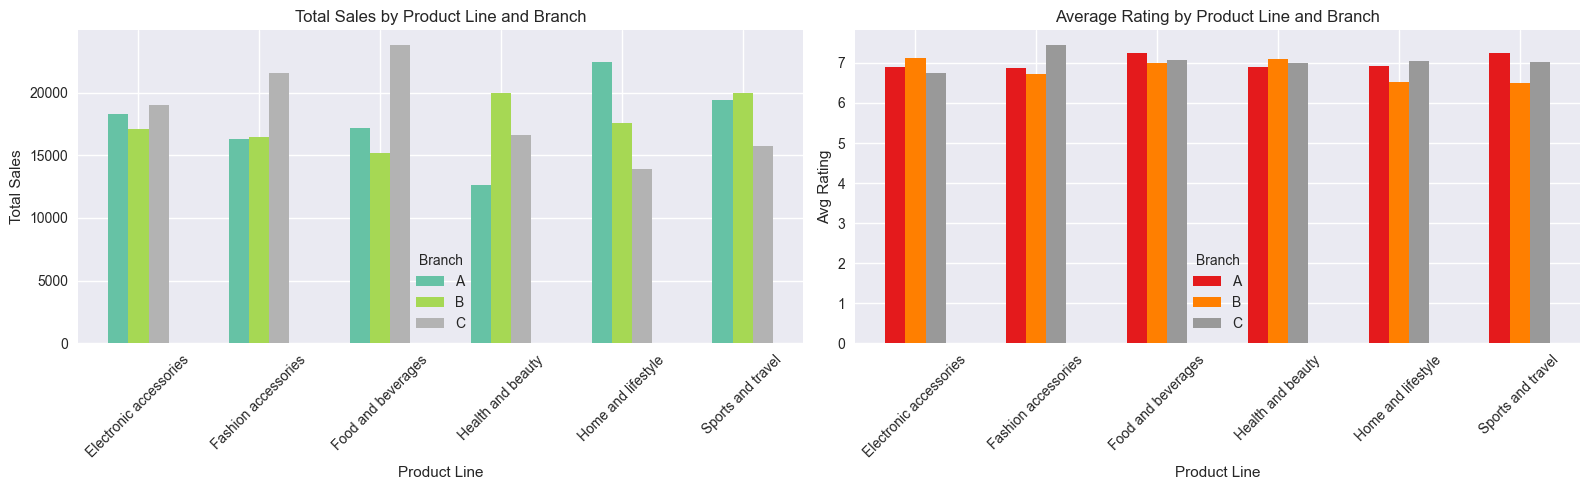

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total sales by product line per branch
pivot = report_df.pivot(
    index="product_line",
    columns="branch_code",
    values="total_sales"
)
pivot.plot(kind="bar", ax=axes[0], colormap="Set2")
axes[0].set_title("Total Sales by Product Line and Branch")
axes[0].set_xlabel("Product Line")
axes[0].set_ylabel("Total Sales")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Branch")

# Avg rating by branch and product line
pivot_rating = report_df.pivot(
    index="product_line",
    columns="branch_code",
    values="avg_rating"
)
pivot_rating.plot(kind="bar", ax=axes[1], colormap="Set1")
axes[1].set_title("Average Rating by Product Line and Branch")
axes[1].set_xlabel("Product Line")
axes[1].set_ylabel("Avg Rating")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Branch")

plt.tight_layout()
plt.show()

In [24]:
# Save report to CSV
report_df.to_csv("report_output.csv", index=False)
print("Report saved to report_output.csv")

# Quick verification check


dim_branch_count = pd.read_sql("SELECT COUNT(*) as rows FROM dim_branch", conn).iloc[0,0]
dim_product_count = pd.read_sql("SELECT COUNT(*) as rows FROM dim_product", conn).iloc[0,0]
fact_sales_count = pd.read_sql("SELECT COUNT(*) as rows FROM fact_sales", conn).iloc[0,0]

print("=== Database Verification ===")
print(f"dim_branch:  {dim_branch_count} rows")
print(f"dim_product: {dim_product_count} rows")
print(f"fact_sales:  {fact_sales_count} rows")

# Close database connection
conn.close()
print("Database connection closed.")
print("ETL pipeline complete!")


Report saved to report_output.csv
=== Database Verification ===
dim_branch:  3 rows
dim_product: 6 rows
fact_sales:  1000 rows
Database connection closed.
ETL pipeline complete!
